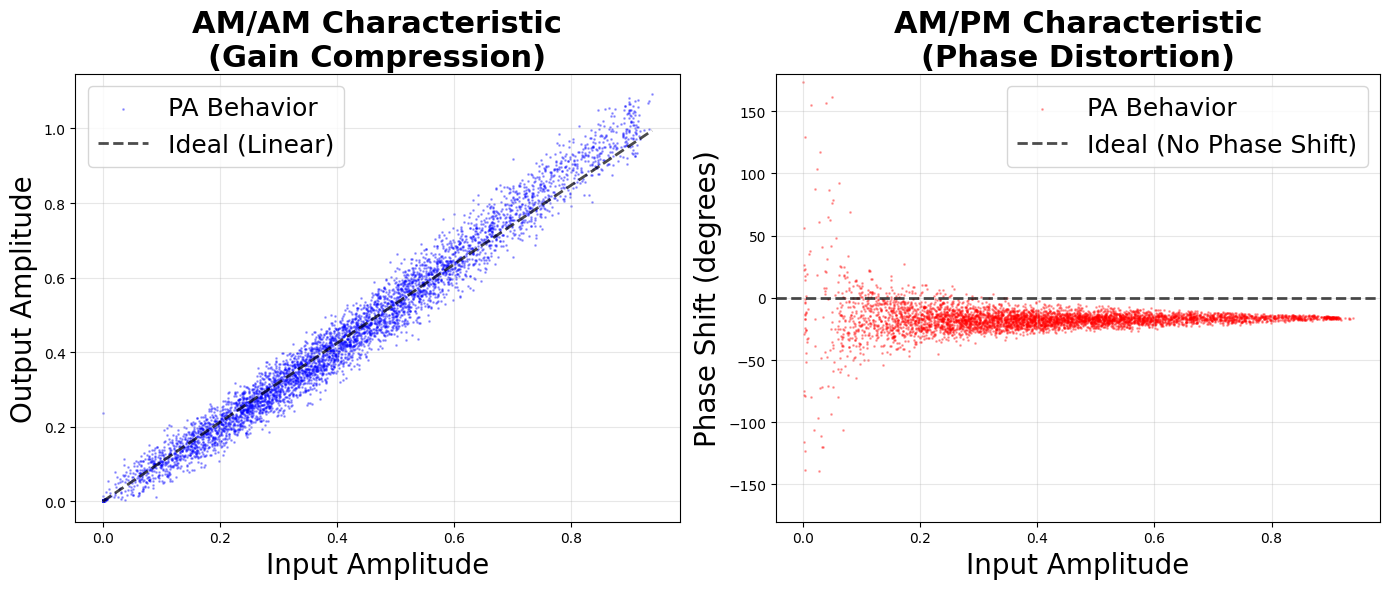


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9384
Output amplitude range: 0.0003 to 1.0917
Estimated small-signal gain: 1.0596
Phase distortion range: -139.61° to 1039.85°
80000


In [1]:
from sparseDPD import DataManager, PNTDNN_NeuralNetwork, Volterra, LinearExperiment, AdaptivePruningExperiment

# Load the ideal predistorted signal, and plot
ideal_predistored_dataset = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='200M_6_5PAPR.mat')

ideal_predistored_dataset.plot_pa_characteristics()

print(len(ideal_predistored_dataset.input_data))

In [3]:
# Print Volterra Performance
volterra_forward_model = Volterra(num_nl_orders=3, num_memory_levels=15, dataset=ideal_predistored_dataset.training_dataset)

print(f" Volterra NMSE: {volterra_forward_model.calculate_volterra_nmse(ideal_predistored_dataset.test_dataset)} dB")

 Volterra NMSE: -36.78570189648688 dB


In [4]:
# Model the ideal predistorted (This will actually be modelled as a forward model)
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True)

# train this model
pntdnn_ideal_predistorted.get_best_model(
    num_epochs = 1000,
    training_dataset=ideal_predistored_dataset.training_dataset,
    validation_dataset=ideal_predistored_dataset.validation_dataset
)

# Save the model, so it can be used later
pntdnn_ideal_predistorted.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model.pt")


Using cuda device
Epoch  10/1000  Loss=1.1843e+03  Valid Loss=1.1044e+02  LR=1.00e-03  NMSE=-7.7072 dB
Epoch  20/1000  Loss=2.0988e+02  Valid Loss=1.7803e+01  LR=1.00e-03  NMSE=-15.6337 dB
Epoch  30/1000  Loss=8.3957e+01  Valid Loss=7.5732e+00  LR=1.00e-03  NMSE=-19.3459 dB
Epoch  40/1000  Loss=4.7880e+01  Valid Loss=4.3724e+00  LR=1.00e-03  NMSE=-21.7314 dB
Epoch  50/1000  Loss=3.0512e+01  Valid Loss=2.8445e+00  LR=1.00e-03  NMSE=-23.5986 dB
Epoch  60/1000  Loss=2.0735e+01  Valid Loss=1.9861e+00  LR=1.00e-03  NMSE=-25.1586 dB
Epoch  70/1000  Loss=1.4842e+01  Valid Loss=1.4610e+00  LR=1.00e-03  NMSE=-26.4921 dB
Epoch  80/1000  Loss=1.1206e+01  Valid Loss=1.1212e+00  LR=1.00e-03  NMSE=-27.6419 dB
Epoch  90/1000  Loss=8.8513e+00  Valid Loss=8.9156e-01  LR=1.00e-03  NMSE=-28.6372 dB
Epoch 100/1000  Loss=7.2064e+00  Valid Loss=7.2841e-01  LR=1.00e-03  NMSE=-29.5149 dB
Epoch 110/1000  Loss=5.9922e+00  Valid Loss=6.0667e-01  LR=1.00e-03  NMSE=-30.3091 dB
Epoch 120/1000  Loss=5.0577e+00  Vali

In [2]:
# Count the number of parameters in the network
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")
pntdnn_ideal_predistorted.get_num_params()

Using cpu device


720

Using cuda device

Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 300 epochs...
Epoch  10/300  Loss=5.7187e-01  Valid Loss=5.7919e-02  LR=1.00e-03  NMSE=-40.5105 dB
Epoch  20/300  Loss=5.6771e-01  Valid Loss=5.5549e-02  LR=1.00e-03  NMSE=-40.6919 dB
Epoch  30/300  Loss=5.7184e-01  Valid Loss=5.4901e-02  LR=1.00e-03  NMSE=-40.7429 dB
Epoch  40/300  Loss=5.9749e-01  Valid Loss=5.4375e-02  LR=1.00e-03  NMSE=-40.7846 dB
Epoch  50/300  Loss=6.1067e-01  Valid Loss=5.3517e-02  LR=1.00e-03  NMSE=-40.8537 dB
Epoch  60/300  Loss=6.0285e-01  Valid Loss=5.2581e-02  LR=1.00e-03  NMSE=-40.9303 dB
Epoch  70/300  Loss=5.9776e-01  Valid Loss=5.2104e-02  LR=1.00e-03  NMSE=-40.9700 dB
Epoch  80/300  Loss=5.9437e-01  Valid Loss=5.1750e-02  LR=1.00e-03  NMSE=-40.9996 dB
Epoch  90/300  Loss=5.9216e-01  Valid Loss=5.1419e-02  LR=1.00e-03  NMSE=-41.0274 dB
Epoch 100/300  Loss=5.8966e-01  Valid Loss=5.1159e-02  LR=1.00e-03  NMSE=-41.0494 

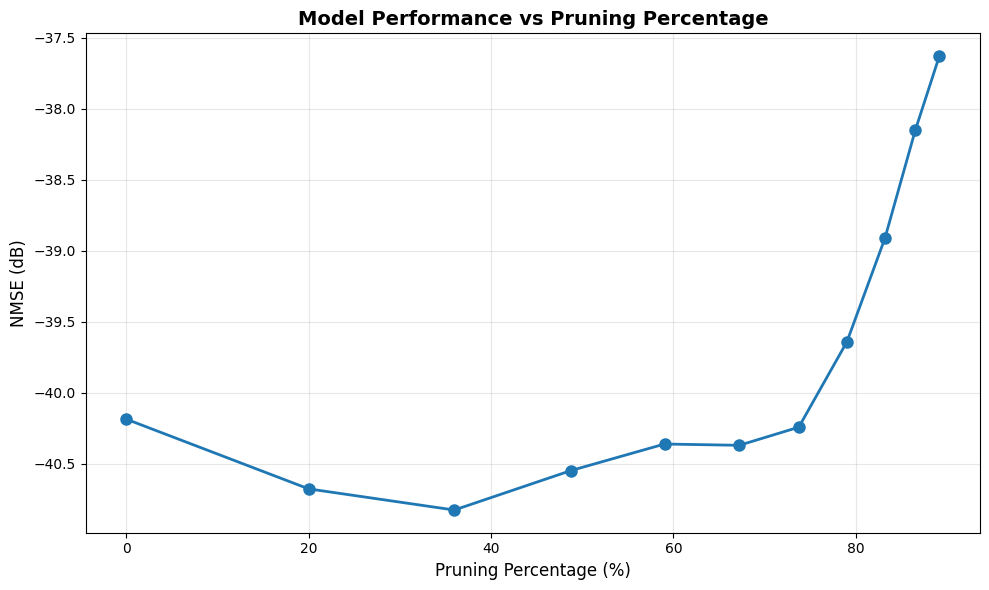

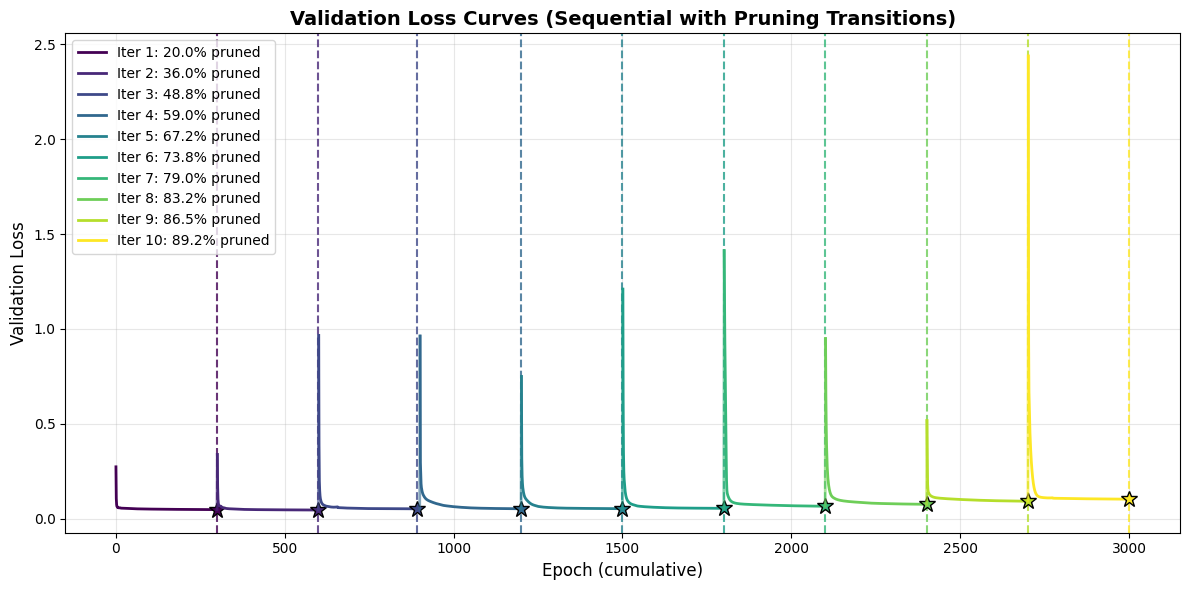

In [5]:
# Linearly prune the model
# Load the model
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

pntdnn_ideal_pruning_experiment = LinearExperiment(
    nn_model= pntdnn_ideal_predistorted,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=300,
    training_dataset=ideal_predistored_dataset.training_dataset,
    valid_dataset=ideal_predistored_dataset.validation_dataset,
    test_dataset=ideal_predistored_dataset.test_dataset,
    nmse_tolerance=-38
)
pntdnn_ideal_pruning_experiment.run()

# Save the best model
pntdnn_ideal_pruning_experiment.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")

Using cuda device
Baseline NMSE          : -40.1854 dB
Tolerance              : +2.19 dB
NMSE must stay below   : -38.0000 dB
Initial prune fraction : 50.0%
Min prune fraction     : 1.0%
Max prune fraction     : 50.0%

Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 300 epochs...
Epoch  10/300  Loss=1.4919e+00  Valid Loss=1.4495e-01  LR=1.00e-03  NMSE=-36.5266 dB
Epoch  20/300  Loss=1.0620e+00  Valid Loss=1.0241e-01  LR=1.00e-03  NMSE=-38.0354 dB
Epoch  30/300  Loss=9.2991e-01  Valid Loss=9.0833e-02  LR=1.00e-03  NMSE=-38.5562 dB
Epoch  40/300  Loss=8.6206e-01  Valid Loss=8.5552e-02  LR=1.00e-03  NMSE=-38.8163 dB
Epoch  50/300  Loss=8.0110e-01  Valid Loss=8.3527e-02  LR=1.00e-03  NMSE=-38.9204 dB
Epoch  60/300  Loss=7.5387e-01  Valid Loss=7.9994e-02  LR=1.00e-03  NMSE=-39.1081 dB
Epoch  70/300  Loss=7.2087e-01  Valid Loss=7.5748e-02  LR=1.00e-03  NMSE=-39.3449 dB
Epoch  80/300  Loss=7.0010e-01  Valid Loss=7

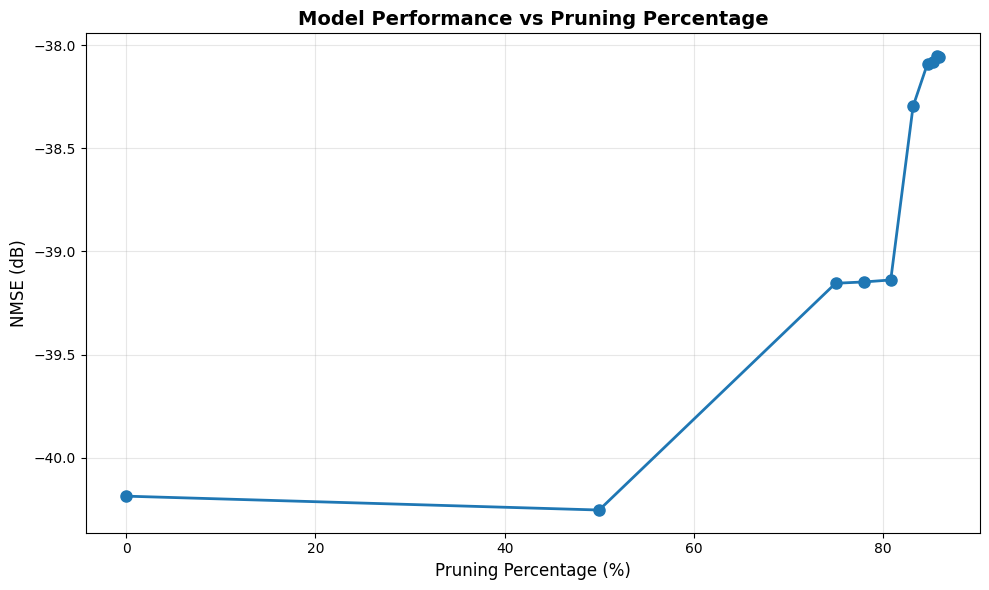

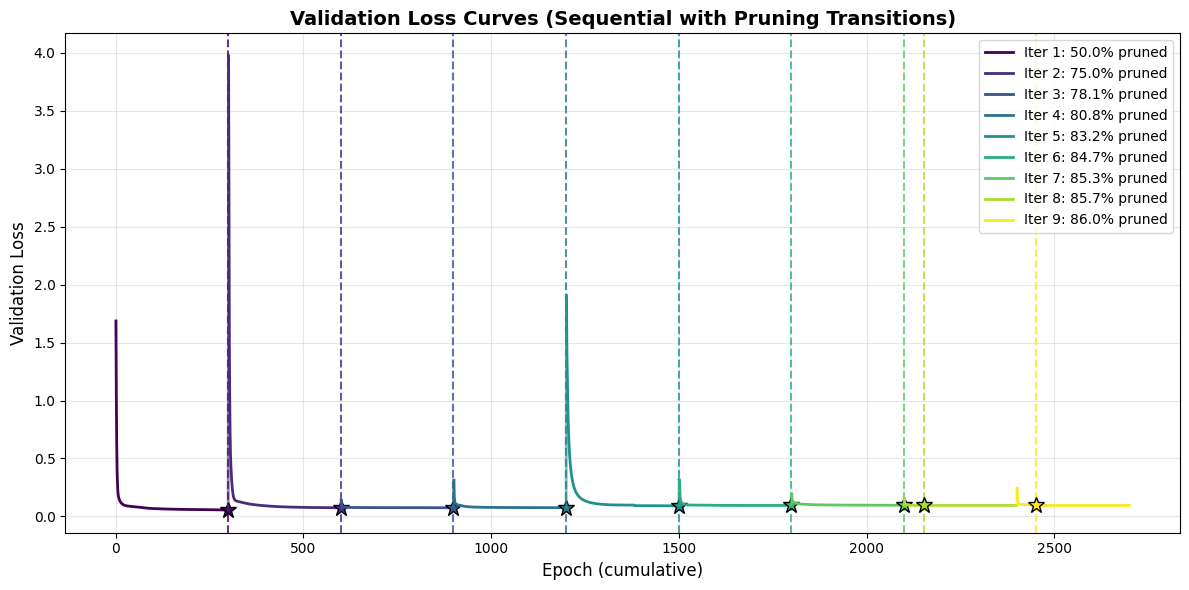

In [6]:
# Use adaptive pruning
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

adaptive_pruning_experiment_PNTDNN = AdaptivePruningExperiment(
    nn_model=pntdnn_ideal_predistorted,
    retrain_epochs= 300,
    training_dataset = ideal_predistored_dataset.training_dataset,
    valid_dataset = ideal_predistored_dataset.validation_dataset,
    test_dataset = ideal_predistored_dataset.test_dataset,
    nmse_threshold = -38,
    initial_prune_fraction=0.5,
    min_prune_fraction=0.01,
    max_prune_fraction=0.5
)

adaptive_pruning_experiment_PNTDNN.run()

# Save the best model
adaptive_pruning_experiment_PNTDNN.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")

In [7]:
# make .mat files for the best models, so they can be used in the future for physical testing
import scipy.io

num_memory_levels = 15
# Load original, adaptive and fixed pruning models
adaptive_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")
fixed_percent_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")
original_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

# Get the full input signal
full_input = ideal_predistored_dataset.input_data

# Generate outputs for each model
print("Generating outputs for each model...")
adaptive_output = adaptive_model.generate_model_output(full_input)
fixed_output = fixed_percent_model.generate_model_output(full_input)
original_output = original_model.generate_model_output(full_input)

# Save to .mat files with 'x' (input) and 'u' (output) naming convention
print("Saving .mat files...")
scipy.io.savemat('adaptive_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': adaptive_output})
scipy.io.savemat('fixed_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': fixed_output})
scipy.io.savemat('original_model_output.mat', {'x1': full_input[num_memory_levels:], 'u': original_output})

print("✓ Saved adaptive_pruned_output.mat")
print("✓ Saved fixed_pruned_output.mat")
print("✓ Saved original_model_output.mat")

Using cuda device
Using cuda device
Using cuda device
Generating outputs for each model...
Saving .mat files...
✓ Saved adaptive_pruned_output.mat
✓ Saved fixed_pruned_output.mat
✓ Saved original_model_output.mat


In [8]:
# Optionally save Volterra model output as well
volterra_output = volterra_forward_model.generate_model_output(full_input)
scipy.io.savemat('volterra_output.mat', {'x1': full_input[num_memory_levels:], 'u': volterra_output})
print("✓ Saved volterra_output.mat")

✓ Saved volterra_output.mat


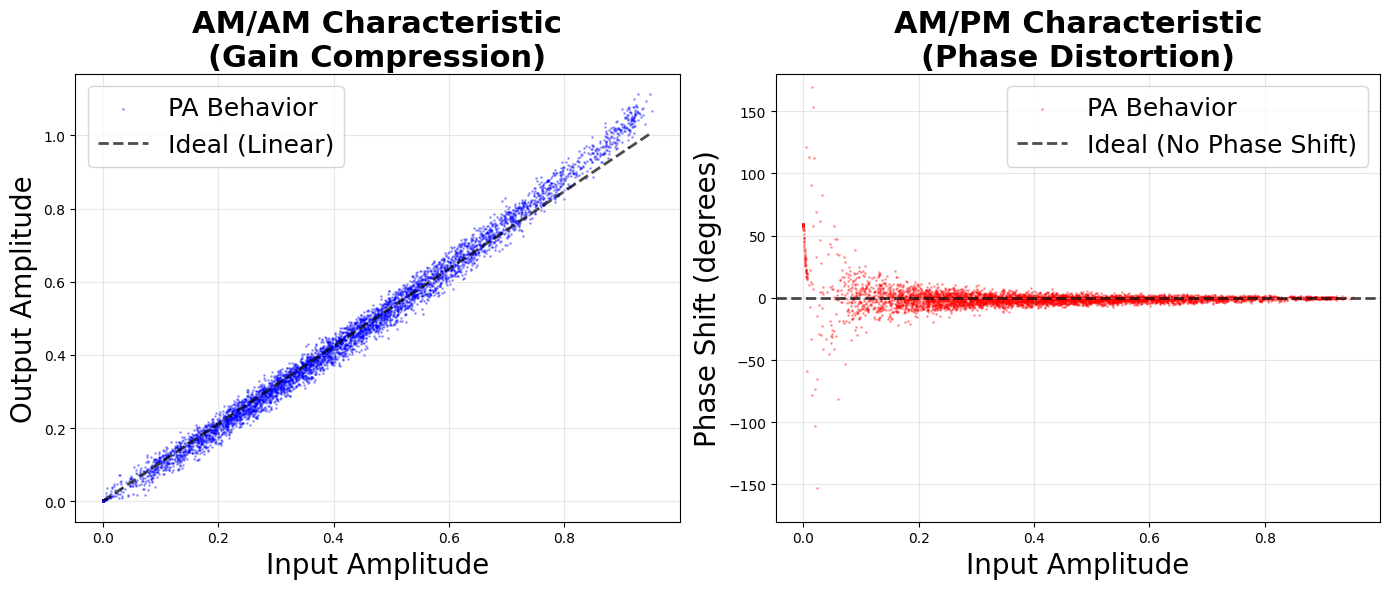


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9520
Output amplitude range: 0.0024 to 1.1121
Estimated small-signal gain: 1.0588
Phase distortion range: -152.59° to 169.79°


In [43]:
test = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='fixed_pruned_output.mat')

test.plot_pa_characteristics()